# GA-DKL: Results Processing and Analysis

This notebook processes and analyzes the results of the GA-DKL closed-loop waveform-discovery campaigns described in *"Closed-loop discovery of out-of-distribution processing protocols by evolutionary search and uncertainty-aware learning."* It reproduces the main results figures: ENL-ratio trajectories across generations, the evolution of the best-performing waveforms and their Fourier spectra, and the spatially resolved before/after PFM comparisons.

**Inputs**

- A campaign archive (`*.npz` saved by the workflow notebook) with two arrays: `waves` (M x 4096 measured waveforms, in generation order) and `y` (M ENL ratios). The main PZT campaign used 32 candidates per generation.
- Raw Igor binary wave (`.ibw`) files saved by the microscope: DART-PFM maps before/after waveform application and switching-spectroscopy loops. These are read with [`aespm`](https://github.com/RichardLiuCoding/aespm).

**Contents**

1. As-grown film overview maps
2. Campaign archive loading and per-generation statistics
3. ENL-ratio trajectories
4. Evolution of the best-performing waveforms
5. Fourier-coefficient analysis of the optimized waveforms
6. PFM maps before and after waveform application
7. Switching-spectroscopy hysteresis loops

The data files are not included in this repository (see the README for availability). Adjust the paths in each loading cell to your local data layout.

## 0. Imports

In [1]:
import os

import numpy as np
import matplotlib.pyplot as plt

import aespm as ae
import aespm.tools as at
import stmpy  # registers the custom colormaps used below

plt.rcParams['font.family'] = 'Arial'

## 1. As-grown film overview

Topography and low-drive DART-PFM piezoresponse of the as-grown PZT film, taken before the campaign (paper Fig. 1b-c).

In [2]:
path_topo = os.path.join('data', '260410', 'PZT3', 'PZT_DART_0000.ibw')

topo = at.load_ibw(path_topo)

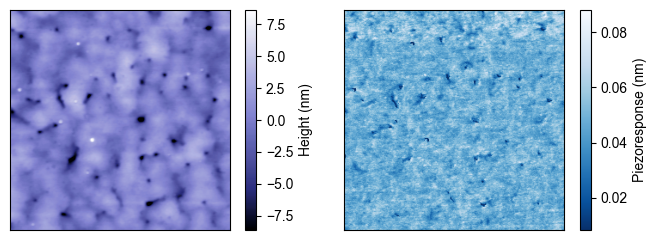

In [3]:
ims = []
factors = [1e9, 1e9*np.cos(topo.data[4]/180*np.pi), 1]
tp1 = topo.data[0] * 1e9
c1 = np.mean(tp1)
s1 = np.std(tp1)

tp2 = topo.data[1] * 1e9*np.cos(topo.data[3]/180*np.pi)
c2 = np.mean(tp2)
s2 = np.std(tp2)

fig, ax = plt.subplots(1,2,figsize=[7,2.5])
im1 = ax[0].imshow(tp1, clim=[c1-5*s1, c1+5*s1], cmap=plt.cm.blue1, origin='lower')
im2 = ax[1].imshow(tp2, clim=[c2-5*s2, c2+5*s2], cmap=plt.cm.Blues_r, origin='lower')
# ax[0].axis('off')
# ax[0].axis('off')
# ax[1].axis('off')
# ax[1].axis('off')

ax[0].set_xticks([])
ax[0].set_yticks([])
ax[1].set_xticks([])
ax[1].set_yticks([])

plt.colorbar(im1, ax=ax[0], label='Height (nm)')
plt.colorbar(im2, ax=ax[1], label='Piezoresponse (nm)')
    
plt.tight_layout()

# plt.savefig('output/topo and domains.png', dpi=400,bbox_inches='tight', pad_inches=0.1)


## 2. Load a campaign archive

Each campaign archive stores every measured waveform and its ENL ratio in generation order. The main PZT campaign contains 2 seeding generations + 40 active-learning generations with 32 candidates each. To analyze a different campaign, point `path1` at the corresponding `.npz` file and set the generation size accordingly.

In [4]:
path1 = os.path.join('data', 'tuning', '260410-PZT-GA-DKL-results3.npz')

d1 = np.load(path1)

In [5]:
y1 = d1['y']
wave1 = d1['waves']

len(y1) / 32

Per-generation statistics: mean, standard deviation, extremes, and the mean of the top/bottom 4 candidates in each generation of 32.

In [6]:
N = len(y1) // 32

y1_ave = np.zeros(N)
y1_std = np.zeros(N)
y1_max = np.zeros(N)
y1_min = np.zeros(N)

y1_max_ave4 = np.zeros(N)
y1_min_ave4 = np.zeros(N)

for i in range(N):
    y1_ave[i] = np.mean(y1[i*32:(i+1)*32])
    y1_std[i] = np.std(y1[i*32:(i+1)*32])
    y1_max[i] = np.max(y1[i*32:(i+1)*32])
    y1_min[i] = np.min(y1[i*32:(i+1)*32])
    
    y1_max_ave4[i] = np.mean(np.sort(y1[i*32:(i+1)*32])[-4:])
    y1_min_ave4[i] = np.mean(np.sort(y1[i*32:(i+1)*32])[:4])
    

## 3. ENL-ratio trajectories

Average ENL ratio per generation (paper Fig. 4a). The upward trend shows the optimizer shifting the whole population toward stronger nonlinear response, not just finding rare outliers.

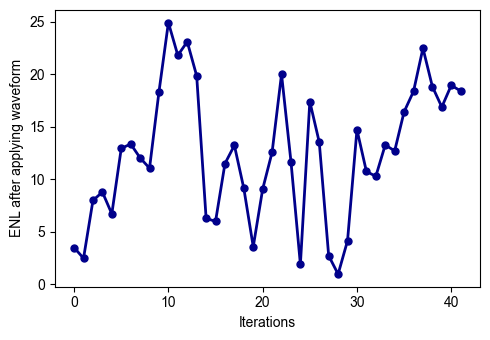

In [7]:
fig, ax = plt.subplots(figsize=(5, 3.5))

x = np.arange(N)

# Uncertainty band
# ax.fill_between(x, y1_min_ave4, y1_max_ave4, alpha=0.25)
# ax.fill_between(x, y1_min, y1_max, alpha=0.25)

# ax.fill_between(x, y1_ave-y1_std, y1_ave+y1_std, alpha=0.25)

# Mean as red dot-line
ax.plot(x, y1_ave, "o-", color="darkblue", linewidth=2, markersize=5)

# ax.axhline(1, linestyle='--', color='gray')

ax.set_xlabel("Iterations")
ax.set_ylabel("ENL after applying waveform")

# ax.set_title("Mean with min/max band")
plt.tight_layout()
plt.savefig('output/Mean of ENL pzt with range only average tune.png', dpi=400,bbox_inches='tight', pad_inches=0.1)


Same trajectory with the band spanning the top-4/bottom-4 averages of each generation:

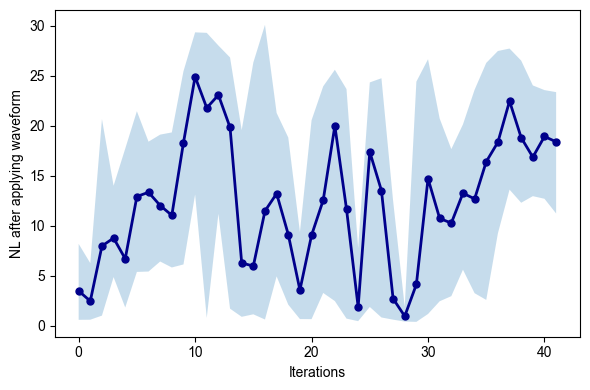

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))


x = np.arange(N)

# Uncertainty band
ax.fill_between(x, y1_min_ave4, y1_max_ave4, alpha=0.25)
# ax.fill_between(x, y1_min, y1_max, alpha=0.25)

# ax.fill_between(x, y1_ave-y1_std, y1_ave+y1_std, alpha=0.25)

# Mean as red dot-line
ax.plot(x, y1_ave, "o-", color="darkblue", linewidth=2, markersize=5)

# ax.axhline(1, linestyle='--', color='gray')

ax.set_xlabel("Iterations")
ax.set_ylabel("NL after applying waveform")
# ax.set_title("Mean with min/max band")
plt.tight_layout()
# plt.savefig('output/Mean of pzt with range tune.png', dpi=400,bbox_inches='tight', pad_inches=0.1)


## 4. Evolution of the best-performing waveforms

For each generation, the four highest-ENL waveforms are averaged to give a representative best waveform. Plotting these as a heatmap against generation number (paper Fig. 4b) shows the search evolving coherently toward temporally structured, multi-harmonic profiles.

In [9]:
y1_array = np.zeros([N, 32])
wave1_array = np.zeros([N, 32, 4096])

for i in range(N):
    y1_array[i] = y1[i*32:(i+1)*32]
    wave1_array[i] = wave1[i*32:(i+1)*32]

idx = np.zeros([N, 4])

wave_temp_array = np.zeros([N, 4, 4096])

for i in range(N):
    idx[i] = np.argsort(y1_array[i])[-4:][::-1]
    # idx[i] = np.argsort(y1_array[i])[:4][::-1]
    # print(idx[i])
    for j in range(4):
        wave_temp_array[i, j] = wave1_array[i][int(idx[i][j])]
    



In [10]:
wave_ave_array = np.mean(wave_temp_array, axis=1)
wave_ave_array.shape

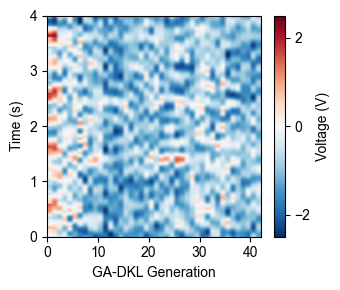

In [11]:
plt.figure(figsize=[3.5,3])
plt.imshow(wave_ave_array.T, extent=[0, 42, 0, 4], clim=[-2.5, 2.5], cmap=plt.cm.RdBu_r, origin='lower', aspect='auto')
plt.colorbar(ticks=[-2, 0, 2], label='Voltage (V)')
plt.xlabel('GA-DKL Generation')
plt.ylabel('Time (s)')
plt.yticks([0, 1, 2, 3, 4])
plt.tight_layout()

Individual best waveforms can be inspected generation by generation, or for a few selected generations (paper Fig. 4c-g):

In [12]:
fig, ax = plt.subplots(11, 4, figsize=[12, 33])
for i in range(N):
    ax.flatten()[i].plot(wave_ave_array[i], label='NL = {:.02f}'.format(y1_max[i]))
    ax.flatten()[i].set_title('Iteration = {}'.format(i))
    ax.flatten()[i].legend()
plt.tight_layout()
# plt.savefig('output/waves of pzt long.png', dpi=1000,bbox_inches='tight', pad_inches=0.1)

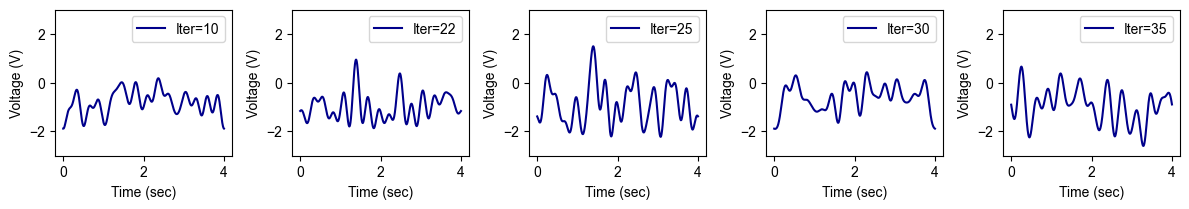

In [13]:
idx_tp = [10, 22, 25, 30, 35]

x_t = np.linspace(0, 4, 4096)

fig, ax = plt.subplots(1, 5, figsize=[12, 2.25])

for i in range(len(idx_tp)):
    ax.flatten()[i].plot(x_t, wave_ave_array[idx_tp[i]], color='darkblue', label='Iter={}'.format(int(idx_tp[i])))
    ax.flatten()[i].set_xlabel('Time (sec)')
    ax.flatten()[i].set_ylabel('Voltage (V)')
    ax.flatten()[i].set_ylim(-3, 3)
    ax.flatten()[i].legend(loc='upper right')
plt.tight_layout()

## 5. Fourier-coefficient analysis

Each best waveform is fitted with the 33-parameter Fourier representation used by the GA (DC + 16 cosine + 16 sine coefficients). The evolution of the coefficients across generations (paper Fig. S2) shows that the optimized waveforms retain several low- and intermediate-order harmonics rather than collapsing to a single-frequency drive.

In [14]:
"""
GA–DKL waveform optimization with Fourier parameterization.

θ parameterization:
  θ = [dc, a1..aK, b1..bK]  length D = 1 + 2K
Waveform:
  x(t) = dc + Σ_{k=1..K} [a_k cos(kt) + b_k sin(kt)], t in [0, 2π)

Workflow:
  1) Initialize population in θ-space:
       - Option A: seed from VAE: z ~ N(0,I) -> waveform -> fit θ by least squares
       - Option B: random θ in bounds
  2) Evaluate a few individuals on the real system (evaluate_waveform)
  3) Train DKL GP on (θ, y_mean) with FixedNoise(y_std^2)
  4) GA evolves θ using surrogate UCB fitness = μ + κσ
  5) Pick top UCB candidates each generation, evaluate them, repeat

Hard safety constraint:
  waveform is globally scaled to satisfy |V(t)| <= VMAX (shape-preserving).
"""

import math
import numpy as np
import torch
import torch.nn as nn
import gpytorch


# =========================================================
# 1) Fourier synthesis / fit
# =========================================================

def fourier_synthesis(theta, T=4096):
    """
    theta: (D,) where D = 1 + 2K
      theta[0] = dc
      theta[1:1+K] = a_k (cos amps)
      theta[1+K:1+2K] = b_k (sin amps)
    returns x: (T,)
    """
    theta = np.asarray(theta, dtype=np.float32)
    D = theta.shape[0]
    assert (D - 1) % 2 == 0
    K = (D - 1) // 2

    dc = theta[0]
    a = theta[1:1+K]
    b = theta[1+K:1+2*K]

    t = np.linspace(0, 2*np.pi, T, endpoint=False, dtype=np.float32)
    x = np.full((T,), dc, dtype=np.float32)
    for k in range(1, K + 1):
        x += a[k-1] * np.cos(k*t) + b[k-1] * np.sin(k*t)
    return x.astype(np.float32)

def fourier_fit(x, K=16):
    """
    Least-squares fit to get theta from a waveform x.
    """
    x = np.asarray(x, dtype=np.float32)
    T = x.shape[0]
    t = np.linspace(0, 2*np.pi, T, endpoint=False, dtype=np.float32)

    cols = [np.ones_like(t)]
    for k in range(1, K+1):
        cols.append(np.cos(k*t))
    for k in range(1, K+1):
        cols.append(np.sin(k*t))
    A = np.stack(cols, axis=1).astype(np.float32)  # (T, 1+2K)

    theta, *_ = np.linalg.lstsq(A, x, rcond=None)
    return theta.astype(np.float32)


In [15]:
wave_ft = np.zeros([42, 33])

for i in range(42):
    wave_ft[i] = fourier_fit(wave_ave_array[i], K=16)

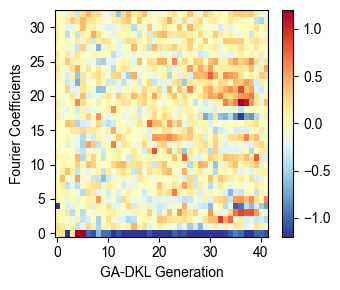

In [16]:
plt.figure(figsize=[3.5,3])
plt.imshow(wave_ft.T, origin='lower', clim=[-1.2, 1.2], cmap=plt.cm.RdYlBu_r, aspect='auto')
plt.colorbar()
plt.ylabel('Fourier Coefficients')
plt.xlabel('GA-DKL Generation')
plt.tight_layout()

Cosine ($a_i$) and sine ($b_i$) coefficients separately:

In [17]:
wave_ft_a = np.zeros([42, 16])
wave_ft_b = np.zeros([42, 16])

for i in range(42):
    wave_ft_a[i] = wave_ft[i, 1::2]
    wave_ft_b[i] = wave_ft[i, 2::2]
    

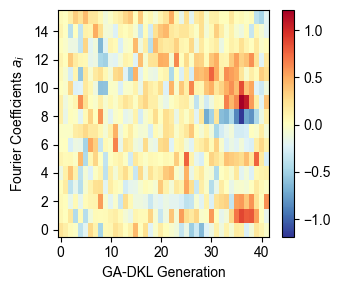

In [18]:
plt.figure(figsize=[3.5,3])
plt.imshow(wave_ft_a.T, origin='lower', cmap=plt.cm.RdYlBu_r, aspect='auto')
plt.colorbar()
plt.ylabel(r'Fourier Coefficients $a_i$')
plt.xlabel('GA-DKL Generation')
plt.tight_layout()

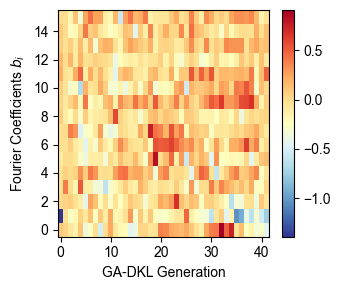

In [19]:
plt.figure(figsize=[3.5,3])
plt.imshow(wave_ft_b.T, origin='lower', cmap=plt.cm.RdYlBu_r, aspect='auto')
plt.colorbar()
plt.ylabel(r'Fourier Coefficients $b_i$')
plt.xlabel('GA-DKL Generation')
plt.tight_layout()

## 6. PFM maps before and after waveform application

DART-PFM piezoresponse maps measured at the same location before and after applying a candidate waveform, together with their difference (change map). High-ENL waveforms leave the mesoscale domain structure largely intact (dispersed, small-amplitude changes); low-ENL waveforms produce a single large, contiguous switched region (paper Fig. 4h-m). The red cross marks the waveform application point.

In [20]:
folder = os.path.join('data', '260402', 'PZT')

In [21]:
b1 = ae.tools.load_ibw(os.path.join(folder, 'PZT_DART_0016.ibw'))
a1 = ae.tools.load_ibw(os.path.join(folder, 'PZT_DART_0014.ibw'))


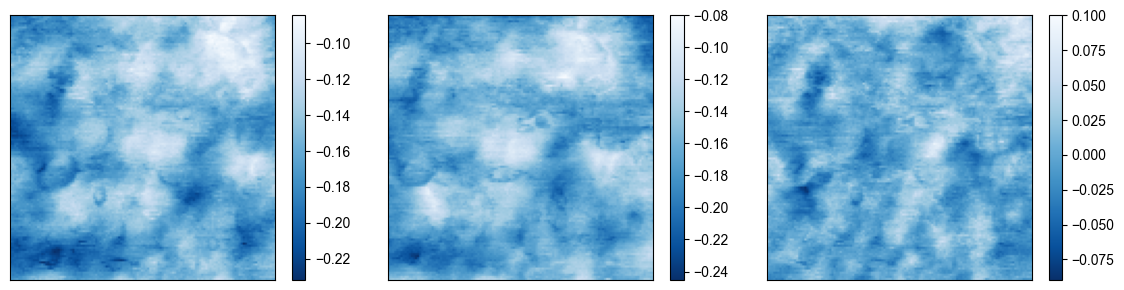

In [22]:
# Piezoresponse (amplitude x cos(phase)) before, after, and change map
tp1 = a1.data[1] * np.cos(a1.data[4]/180*np.pi) * 1e9
tp2 = b1.data[1] * np.cos(b1.data[4]/180*np.pi) * 1e9

fig, ax = plt.subplots(1,3,figsize=[11.5, 3])
tps = [tp2, tp1, tp2-tp1]
cbars = []
for i in range(3):
    cbars.append(ax[i].imshow(tps[i], origin='lower', cmap=plt.cm.Blues_r))
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    plt.colorbar(cbars[i], ax=ax[i])
plt.tight_layout()

The same comparison using the phase channel:

In [23]:
tp1 = a1.data[3]
tp2 = b1.data[3]

L = len(tp1)

fig, ax = plt.subplots(1,3,figsize=[11.5, 3])
tps = [tp2, tp1, tp1-tp2]
cbars = []
for i in range(3):
    cbars.append(ax[i].imshow(tps[i], origin='lower', cmap=plt.cm.copper))
    ax[i].set_xticks([])
    ax[i].set_yticks([])
    ax[i].plot(L//2, L//2, 'rx', ms=10, mew=2)

    plt.colorbar(cbars[i], ax=ax[i])
plt.tight_layout()

# plt.savefig(os.path.join('output', 'Example of good waveform phase.png'), dpi=400, bbox_inches='tight', pad_inches=0.1)


### Batch comparison for the best and worst waveforms

A folder of paired `PZT_before_*/PZT_after_*` maps is loaded and split into the locations where the highest-ENL (`max`) and lowest-ENL (`min`) waveforms were applied. The loops below save a before/after/change figure for every pair (outputs cleared here to keep the notebook small; figures are written to `output/switching/`).

In [24]:
folder = os.path.join('data', '260402', 'PZT2')

In [25]:
files = sorted(os.listdir(folder))

f_before = []
f_after = []

for f in files:
    if f.startswith('PZT_after'):
        f_after.append(f)
    elif f.startswith('PZT_before'):
        f_before.append(f)
print(len(f_after), len(f_before))

In [26]:
topo_before_min = []
topo_after_min = []

topo_before_max = []
topo_after_max = []

for i in range(len(f_after)):
    if i % 2 == 0:
        topo_after_max.append(ae.tools.load_ibw(os.path.join(folder, f_after[i])))
        topo_before_max.append(ae.tools.load_ibw(os.path.join(folder, f_before[i])))
    else:
        topo_after_min.append(ae.tools.load_ibw(os.path.join(folder, f_after[i])))
        topo_before_min.append(ae.tools.load_ibw(os.path.join(folder, f_before[i])))

In [27]:

for k in range(len(topo_before_max)):
    a = topo_after_max[k]
    b = topo_before_max[k]
    
    tp1 = a.data[3]
    tp2 = b.data[3]
    
    L = len(tp1)
    
    fig, ax = plt.subplots(1,3,figsize=[11.5, 3])
    tps = [tp2, tp1, tp1-tp2]
    cbars = []
    for i in range(3):
        cbars.append(ax[i].imshow(tps[i], origin='lower', cmap=plt.cm.copper))
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].plot(L//2, L//2, 'rx', ms=10, mew=2)
    
        plt.colorbar(cbars[i], ax=ax[i])
    plt.tight_layout()
    
    plt.savefig(os.path.join('output', 'switching', 'waveform phase max {}.png').format(k), dpi=400, bbox_inches='tight', pad_inches=0.1)



In [28]:
for k in range(len(topo_before_min)):
    a = topo_after_min[k]
    b = topo_before_min[k]

    tp1 = a.data[3]
    tp2 = b.data[3]

    L = len(tp1)

    fig, ax = plt.subplots(1,3,figsize=[11.5, 3])
    tps = [tp2, tp1, tp1-tp2]
    cbars = []
    for i in range(3):
        cbars.append(ax[i].imshow(tps[i], origin='lower', cmap=plt.cm.copper))
        ax[i].set_xticks([])
        ax[i].set_yticks([])
        ax[i].plot(L//2, L//2, 'rx', ms=10, mew=2)

        plt.colorbar(cbars[i], ax=ax[i])
    plt.tight_layout()

    plt.savefig(os.path.join('output', 'switching', 'waveform phase min {}.png').format(k), dpi=400, bbox_inches='tight', pad_inches=0.1)

## 7. Switching-spectroscopy hysteresis loops

Local piezoresponse and phase hysteresis loops (paper Fig. 1d), confirming the ferroelectric character of the film and the coercive voltage (~2.5-3 V) that bounds the small-signal readout range.

In [29]:
folder = os.path.join('data', '260403', 'PZT')

ss = ae.tools.load_ibw(os.path.join(folder, 'PZT_SS_0001.ibw'), ss=True)

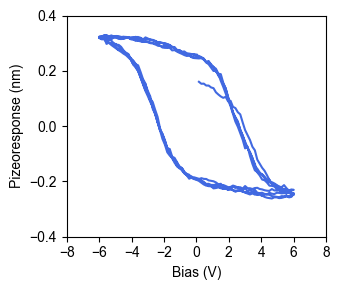

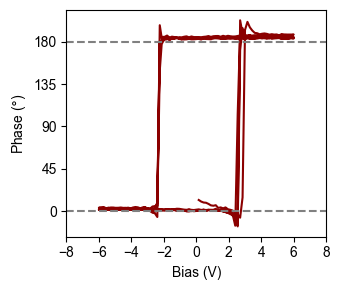

In [30]:
plt.figure(figsize=[3.5,3])
plt.plot(ss.bias, ss.amp2_off*np.cos(ss.phase1_off/180*np.pi) * 1e9, color='royalblue')
plt.xlabel('Bias (V)')
plt.ylabel('Piezoresponse (nm)')
plt.xlim(-8, 8)
plt.xticks([-8, -6, -4, -2, 0, 2, 4, 6, 8])
plt.ylim(-0.4, 0.4)
plt.tight_layout()

plt.figure(figsize=[3.5,3])
plt.plot(ss.bias, ss.phase1_off, color='darkred')
plt.xlabel('Bias (V)')
plt.ylabel(r'Phase ($\degree$)')
plt.xlim(-8, 8)
plt.xticks([-8, -6, -4, -2, 0, 2, 4, 6, 8])
plt.tight_layout()